In [1]:
"""
Analysis helper for the temporal-discounting experiment.

Usage
-----
$ python -m experiments.temporal_discounting.analyze_results
# prints the DataFrame

You can also import ``load_temporal_discounting_results`` from notebooks.
"""


import pandas as pd

from bias_in_llms.database.temporal_discounting_db import (
    select_all_temporal_discounting,
)

# ---------------------------------------------------------------------------

# DEFAULT_DB = DATA_DIR / "temporal_discounting_results.db"

In [5]:
df = select_all_temporal_discounting()

In [7]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)  # show all columns
df.head(100)

,id,run,now_value,later_value,delay_years,preference,full_prompt,question,option_a,option_b,answer,model_id,reasoning_model,reasoning_tokens,temperature,created_at
0,1,1,1000.0,1010.00,1,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1010.0 in 1 years,Receive $1000 today,B,GPT4O_mini,False,0,0.0,2025-08-26 09:25:48.676470
1,2,1,1000.0,1020.10,2,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1020.1 in 2 years,Receive $1000 today,B,GPT4O_mini,False,0,0.0,2025-08-26 09:25:53.702554
2,3,1,1000.0,1030.30,3,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1000 today,Receive $1030.3 in 3 years,A,GPT4O_mini,False,0,0.0,2025-08-26 09:25:54.861827
3,4,1,1000.0,1040.60,4,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1040.6 in 4 years,Receive $1000 today,B,GPT4O_mini,False,0,0.0,2025-08-26 09:25:55.722227
4,5,1,1000.0,1051.01,5,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1000 today,Receive $1051.01 in 5 years,A,GPT4O_mini,False,0,0.0,2025-08-26 09:25:56.670611
5,6,1,1000.0,1061.52,6,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1061.52 in 6 years,Receive $1000 today,B,GPT4O_mini,False,0,0.0,2025-08-26 09:25:57.348428
6,7,1,1000.0,1072.14,7,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1000 today,Receive $1072.14 in 7 years,A,GPT4O_mini,False,0,0.0,2025-08-26 09:25:58.043816
7,8,1,1000.0,1082.86,8,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1082.86 in 8 years,Receive $1000 today,B,GPT4O_mini,False,0,0.0,2025-08-26 09:25:58.625438
8,9,1,1000.0,1093.69,9,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1000 today,Receive $1093.69 in 9 years,A,GPT4O_mini,False,0,0.0,2025-08-26 09:25:59.396332
9,10,1,1000.0,1104.62,10,Now,\n\nChoose one of the following options:\n(A) ...,Choose one of the following options:,Receive $1104.62 in 10 years,Receive $1000 today,B,GPT4O_mini,False,0,0.0,2025-08-26 09:26:00.054713


In [8]:
df["now_value"].value_counts()

now_value
1.000000e+03    100
1.000000e+05    100
1.000000e+07    100
1.000000e+09    100
Name: count, dtype: int64

In [5]:
# Additional imports for discount function fitting
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

warnings.filterwarnings("ignore")

# Set up plotting
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)

In [ ]:
# Prepare data for analysis
# Convert preference to binary (1 = choose later, 0 = choose now)
df["choose_later"] = (df["Preference"] == "Later").astype(int)

# Calculate implied interest rate from the scenario
df["implied_rate"] = (df["Later ($)"] / df["Now ($)"]) ** (1 / df["Delay (years)"]) - 1

print(f"Data shape: {df.shape}")
print(f"\nModels in dataset: {df['LLM'].unique()}")
print("\nChoice distribution:")
print(df["Preference"].value_counts())
print(
    f"\nImplied interest rates range: "
    f"{df['implied_rate'].min():.1%} to {df['implied_rate'].max():.1%}"
)

Data shape: (1200, 8)

Models in dataset: ['GPT4O_mini' 'GPT4O' 'O3']

Choice distribution:
Preference
Now      940
Later    260
Name: count, dtype: int64

Implied interest rates range: 1.0% to 10.0%


In [ ]:
# Define discount functions
def exponential_discount(amount, delay, k):
    """
    Exponential discount function.

    V = A * exp(-k * t)

    Parameters:
    - amount: monetary amount
    - delay: time delay in years
    - k: discount rate parameter
    """
    return amount * np.exp(-k * delay)


def hyperbolic_discount(amount, delay, k):
    """
    Hyperbolic discount function.

    V = A / (1 + k * t)

    Parameters:
    - amount: monetary amount
    - delay: time delay in years
    - k: discount rate parameter
    """
    return amount / (1 + k * delay)


def choice_probability(sv_later, sv_now, beta=1.0):
    """
    Logistic choice probability.

    P(choose later) = 1 / (1 + exp(-beta * (SV_later - SV_now)))

    Parameters:
    - sv_later: subjective value of later option
    - sv_now: subjective value of now option
    - beta: choice sensitivity parameter
    """
    value_diff = sv_later - sv_now
    return 1 / (1 + np.exp(-beta * value_diff))

In [ ]:
# Fitting functions
def fit_discount_model(data, discount_function):
    """
    Fit a discount model to choice data using maximum likelihood estimation.

    Parameters:
    - data: DataFrame with choice data for one model
    - discount_function: either exponential_discount or hyperbolic_discount

    Returns:
    - dict with fitted parameters and goodness of fit metrics
    """

    def negative_log_likelihood(params):
        k, beta = params

        # Avoid negative or extreme values
        if k <= 0 or k > 10 or beta <= 0 or beta > 100:
            return 1e6

        # Calculate subjective values
        sv_now = data["Now ($)"].values  # No discounting for immediate rewards
        sv_later = discount_function(
            data["Later ($)"].values, data["Delay (years)"].values, k
        )

        # Calculate choice probabilities
        prob_later = choice_probability(sv_later, sv_now, beta)

        # Ensure probabilities are in valid range
        prob_later = np.clip(prob_later, 1e-10, 1 - 1e-10)

        # Calculate log likelihood
        choices = data["choose_later"].values
        log_likelihood = np.sum(
            choices * np.log(prob_later) + (1 - choices) * np.log(1 - prob_later)
        )

        return -log_likelihood

    # Initial parameter guesses
    initial_guess = [0.1, 1.0]  # [k, beta]

    # Optimize
    result = minimize(
        negative_log_likelihood,
        initial_guess,
        method="L-BFGS-B",
        bounds=[(0.001, 10), (0.1, 100)],
    )

    if result.success:
        k_fitted, beta_fitted = result.x
        neg_log_likelihood = result.fun

        # Calculate additional metrics
        n_params = 2
        n_obs = len(data)
        aic = 2 * n_params + 2 * neg_log_likelihood
        bic = n_params * np.log(n_obs) + 2 * neg_log_likelihood

        # Calculate predicted probabilities for R²
        # sv_now = data["Now ($)"].values
        # sv_later = discount_function(
        #     data["Later ($)"].values, data["Delay (years)"].values, k_fitted
        # )
        # pred_prob = choice_probability(sv_later, sv_now, beta_fitted)

        # McFadden's pseudo R²
        null_likelihood = n_obs * np.log(0.5)  # Assuming 50/50 choice probability
        pseudo_r2 = 1 - neg_log_likelihood / (-null_likelihood)

        return {
            "k": k_fitted,
            "beta": beta_fitted,
            "neg_log_likelihood": neg_log_likelihood,
            "aic": aic,
            "bic": bic,
            "pseudo_r2": pseudo_r2,
            "n_obs": n_obs,
            "success": True,
        }
    else:
        return {"success": False, "message": result.message}

In [ ]:
# Fit models for each LLM
results = []

for model in df["LLM"].unique():
    model_data = df[df["LLM"] == model].copy()

    print(f"\nFitting models for {model} ({len(model_data)} observations)...")

    # Fit exponential model
    exp_result = fit_discount_model(model_data, exponential_discount)

    # Fit hyperbolic model
    hyp_result = fit_discount_model(model_data, hyperbolic_discount)

    if exp_result["success"] and hyp_result["success"]:
        # Determine which model fits better (lower AIC = better)
        better_model = (
            "Exponential" if exp_result["aic"] < hyp_result["aic"] else "Hyperbolic"
        )
        aic_difference = abs(exp_result["aic"] - hyp_result["aic"])

        # Store results
        results.append(
            {
                "Model": model,
                "Exponential_k": exp_result["k"],
                "Exponential_AIC": exp_result["aic"],
                "Exponential_BIC": exp_result["bic"],
                "Exponential_R2": exp_result["pseudo_r2"],
                "Hyperbolic_k": hyp_result["k"],
                "Hyperbolic_AIC": hyp_result["aic"],
                "Hyperbolic_BIC": hyp_result["bic"],
                "Hyperbolic_R2": hyp_result["pseudo_r2"],
                "Better_Model": better_model,
                "AIC_Difference": aic_difference,
                "N_Observations": exp_result["n_obs"],
            }
        )

        print(
            f"  Exponential: k={exp_result['k']:.4f}, "
            f"AIC={exp_result['aic']:.2f}, "
            f"R²={exp_result['pseudo_r2']:.3f}"
        )
        print(
            f"  Hyperbolic:  k={hyp_result['k']:.4f}, "
            f"AIC={hyp_result['aic']:.2f}, "
            f"R²={hyp_result['pseudo_r2']:.3f}"
        )
        print(f"  Better model: {better_model} (ΔAIC = {aic_difference:.2f})")
    else:
        print(f"  Failed to fit models for {model}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("SUMMARY RESULTS")
print("=" * 80)
print(results_df.to_string(index=False))


Fitting models for GPT4O_mini (400 observations)...
  Exponential: k=0.4453, AIC=2675.00, R²=-3.817
  Hyperbolic:  k=0.1645, AIC=2675.00, R²=-3.817
  Better model: Exponential (ΔAIC = 0.00)

Fitting models for GPT4O (400 observations)...
  Exponential: k=0.0960, AIC=54.54, R²=0.909
  Hyperbolic:  k=0.1671, AIC=96.10, R²=0.834
  Better model: Exponential (ΔAIC = 41.56)

Fitting models for O3 (400 observations)...
  Exponential: k=0.0488, AIC=1182.13, R²=-1.125
  Hyperbolic:  k=0.0588, AIC=1282.18, R²=-1.305
  Better model: Exponential (ΔAIC = 100.05)

SUMMARY RESULTS
     Model  Exponential_k  Exponential_AIC  Exponential_BIC  Exponential_R2  Hyperbolic_k  Hyperbolic_AIC  Hyperbolic_BIC  Hyperbolic_R2 Better_Model  AIC_Difference  N_Observations
GPT4O_mini       0.445319      2674.998708      2682.981637       -3.816796      0.164497     2674.998708     2682.981637      -3.816796  Exponential    8.572897e-09             400
     GPT4O       0.095966        54.539250        62.522179   

In [ ]:
# Model comparison analysis
if not results_df.empty:
    print("\nMODEL COMPARISON SUMMARY")
    print("=" * 50)

    # Count which model type wins
    model_wins = results_df["Better_Model"].value_counts()
    print("\nModel preference across LLMs:")
    for model_type, count in model_wins.items():
        pct = count / len(results_df) * 100
        print(f"  {model_type}: {count}/{len(results_df)} ({pct:.1f}%)")

    # Average discount rates
    print("\nAverage discount rates (k parameter):")
    print(
        f"  Exponential: {results_df['Exponential_k'].mean():.4f} ± "
        f"{results_df['Exponential_k'].std():.4f}"
    )
    print(
        f"  Hyperbolic:  {results_df['Hyperbolic_k'].mean():.4f} ± "
        f"{results_df['Hyperbolic_k'].std():.4f}"
    )

    # Model fit quality
    print("\nAverage model fit (Pseudo R²):")
    print(
        f"  Exponential: {results_df['Exponential_R2'].mean():.3f} ± "
        f"{results_df['Exponential_R2'].std():.3f}"
    )
    print(
        f"  Hyperbolic:  {results_df['Hyperbolic_R2'].mean():.3f} ± "
        f"{results_df['Hyperbolic_R2'].std():.3f}"
    )

    # Significant model differences (AIC difference > 2 is meaningful)
    significant_diff = results_df["AIC_Difference"] > 2
    print(
        f"\nModels with significant fit differences (ΔAIC > 2): "
        f"{significant_diff.sum()}/{len(results_df)}"
    )

    if significant_diff.any():
        print("\nLLMs with strong model preferences:")
        sig_results = results_df[significant_diff][
            ["Model", "Better_Model", "AIC_Difference"]
        ]
        for _, row in sig_results.iterrows():
            print(
                f"  {row['Model']}: {row['Better_Model']} "
                f"(ΔAIC = {row['AIC_Difference']:.2f})"
            )


MODEL COMPARISON SUMMARY

Model preference across LLMs:
  Exponential: 3/3 (100.0%)

Average discount rates (k parameter):
  Exponential: 0.1967 ± 0.2166
  Hyperbolic:  0.1301 ± 0.0618

Average model fit (Pseudo R²):
  Exponential: -1.344 ± 2.370
  Hyperbolic:  -1.429 ± 2.328

Models with significant fit differences (ΔAIC > 2): 2/3

LLMs with strong model preferences:
  GPT4O: Exponential (ΔAIC = 41.56)
  O3: Exponential (ΔAIC = 100.05)


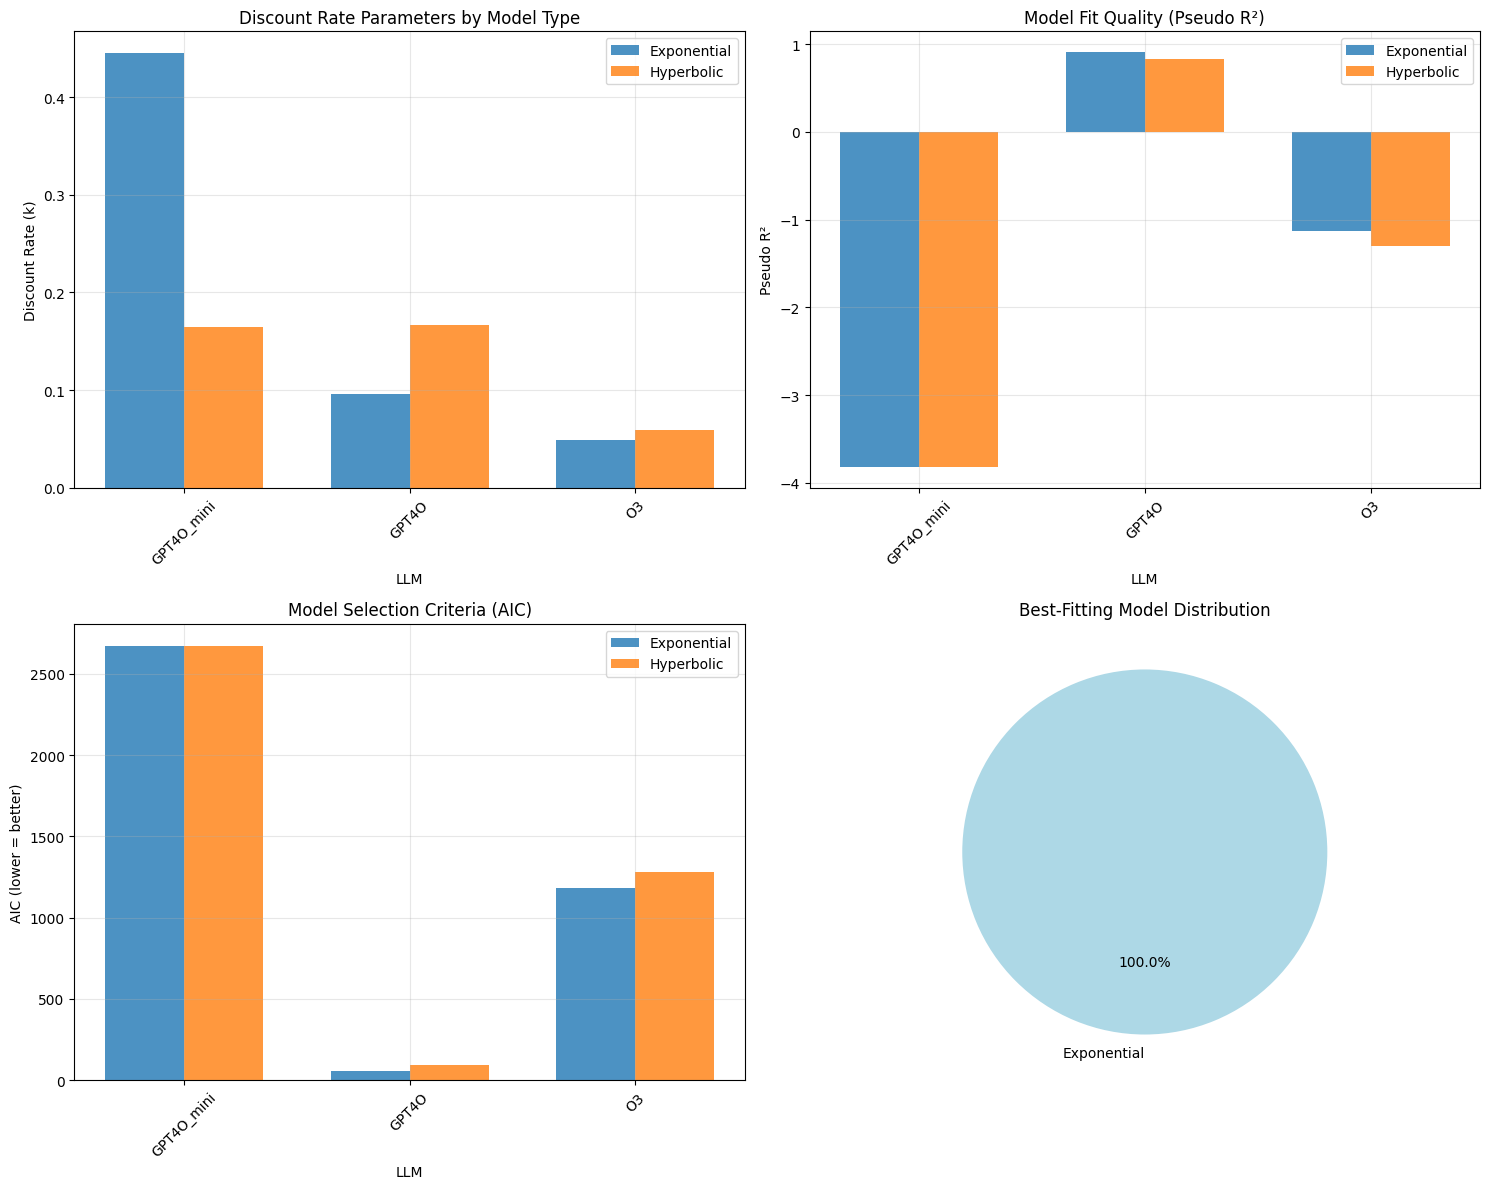


KEY INSIGHTS
Most 'rational' (exponential) LLMs: GPT4O_mini, GPT4O, O3

Most impatient (highest exponential k): GPT4O_mini (k=0.4453)
Most patient (lowest exponential k): O3 (k=0.0488)


In [ ]:
# Visualization of results
if not results_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Discount rates comparison
    ax1 = axes[0, 0]
    x = np.arange(len(results_df))
    width = 0.35

    ax1.bar(
        x - width / 2,
        results_df["Exponential_k"],
        width,
        label="Exponential",
        alpha=0.8,
    )
    ax1.bar(
        x + width / 2,
        results_df["Hyperbolic_k"],
        width,
        label="Hyperbolic",
        alpha=0.8,
    )
    ax1.set_xlabel("LLM")
    ax1.set_ylabel("Discount Rate (k)")
    ax1.set_title("Discount Rate Parameters by Model Type")
    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df["Model"], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Model fit comparison (R²)
    ax2 = axes[0, 1]
    ax2.bar(
        x - width / 2,
        results_df["Exponential_R2"],
        width,
        label="Exponential",
        alpha=0.8,
    )
    ax2.bar(
        x + width / 2,
        results_df["Hyperbolic_R2"],
        width,
        label="Hyperbolic",
        alpha=0.8,
    )
    ax2.set_xlabel("LLM")
    ax2.set_ylabel("Pseudo R²")
    ax2.set_title("Model Fit Quality (Pseudo R²)")
    ax2.set_xticks(x)
    ax2.set_xticklabels(results_df["Model"], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. AIC comparison
    ax3 = axes[1, 0]
    ax3.bar(
        x - width / 2,
        results_df["Exponential_AIC"],
        width,
        label="Exponential",
        alpha=0.8,
    )
    ax3.bar(
        x + width / 2,
        results_df["Hyperbolic_AIC"],
        width,
        label="Hyperbolic",
        alpha=0.8,
    )
    ax3.set_xlabel("LLM")
    ax3.set_ylabel("AIC (lower = better)")
    ax3.set_title("Model Selection Criteria (AIC)")
    ax3.set_xticks(x)
    ax3.set_xticklabels(results_df["Model"], rotation=45)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Model preference pie chart
    ax4 = axes[1, 1]
    model_wins = results_df["Better_Model"].value_counts()
    colors = ["lightblue", "lightcoral"]
    ax4.pie(
        model_wins.values,
        labels=model_wins.index,
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
    )
    ax4.set_title("Best-Fitting Model Distribution")

    plt.tight_layout()
    plt.show()

    # Summary statistics
    print("\nKEY INSIGHTS")
    print("=" * 40)

    # Which models are most "rational" (exponential) vs "human-like"
    exp_models = results_df[results_df["Better_Model"] == "Exponential"][
        "Model"
    ].tolist()
    hyp_models = results_df[results_df["Better_Model"] == "Hyperbolic"][
        "Model"
    ].tolist()

    if exp_models:
        print(f"Most 'rational' (exponential) LLMs: {', '.join(exp_models)}")
    if hyp_models:
        print(f"Most 'human-like' (hyperbolic) LLMs: {', '.join(hyp_models)}")

    # Identify models with extreme discount rates
    high_discount_exp = results_df.loc[results_df["Exponential_k"].idxmax()]
    low_discount_exp = results_df.loc[results_df["Exponential_k"].idxmin()]

    print(
        f"\nMost impatient (highest exponential k): "
        f"{high_discount_exp['Model']} "
        f"(k={high_discount_exp['Exponential_k']:.4f})"
    )
    print(
        f"Most patient (lowest exponential k): {low_discount_exp['Model']} "
        f"(k={low_discount_exp['Exponential_k']:.4f})"
    )